In [1]:
from cosipy import BinnedData, UnBinnedData#, COSILike
# from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response import FullDetectorResponse, PointSourceResponse, GalacticResponse
from cosipy.response.functions import get_integrated_spectral_model
from cosipy.ts_map import FastNormFit, FastTSMap

# from COSILikeNew import COSILike

from scoords import SpacecraftFrame

import astropy.units as u
import astropy.constants as const
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
from scipy.special import gammaln
import pandas as pd
from lmfit import Model
from lmfit.models import GaussianModel

from threeML import Line, Gaussian, Cauchy, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter
from histpy import Histogram, Axes, Axis, HealpixAxis
from tqdm import tqdm
import mhealpy as hp

from pathlib import Path

import os

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['orange', 'limegreen', 'b', 'r']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

12:53:17 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=19669;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=770703;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=946043;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=251878;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=712232;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=748247;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=528852;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=157603;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

12:53:19 WARNING   No fermitools installed                                              ]8;id=67255;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=396195;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=496267;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=989084;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=809729;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=972314;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=805921;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=408278;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
DATA_DIR = Path('/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC4/')

In [4]:
fdr_filename = DATA_DIR / 'data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse.h5'
psr_filename = DATA_DIR / 'data/responses/extended_source_response_Ti44_merged.h5'

In [184]:
with FullDetectorResponse.open(fdr_filename) as f:
    print(f.__dict__)
    print(f.get_counts(1816).shape)
    print(f[1816].contents.shape)

{'_file': <HDF5 file "Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse.h5" (mode r)>, '_drm': <HDF5 group "/DRM" (5 members)>, '_axes': <histpy.axes.Axes object at 0x404087760>, '_rest_axes': <histpy.axes.Axes object at 0x4040bd330>, '_unit': Unit("cm2"), '_eff_area': array([7.25766574e-06]), '_pix_rangesets': None, '_pix_rangesets_argsort': None, '_uniq': None, '_scheme': 'RING', '_order': 4, '_coordsys': <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>, '_npix_ratio_max': 1125899906842624, 'pa_convention': None, '_counts': <HDF5 dataset "COUNTS": shape (3072, 1, 1, 60, 3072), type "<u2">}
(1, 1, 60, 3072)
(1, 1, 60, 3072)


In [ ]:
# hist = Histogram.open(psr_filename)
# psr = PointSourceResponse(hist.axes,
#                           contents=hist.contents,
#                           sparse=hist.is_sparse,
#                           unit=hist.unit)

In [5]:
psr = GalacticResponse.open(psr_filename)

In [101]:
ts_results = np.zeros((n_samples, psr.axes['NuLambda'].edges[-1]))

In [ ]:
# Create a FastTSMap object. Will fit the TS map in the following cells.
for i in range(750,1000):
    data = Histogram(bg.binned_data.project('Em', 'Phi', 'PsiChi').axes, n_sr[i], sparse=False)

    ts = FastTSMap(
                data = data, 
                bkg_model = loc_br, 
                orientation = None, 
                response_path = psr_filename, 
                cds_frame = "galactic",
                )
    
    energy_channel=[0, 1]

    data_cds_array, bkg_model_cds_array, psr_cache = \
        ts._prepare_inputs(energy_channel, spectrum, max_cache_size=None)

    hyp_frame = "galactic"

    hypothesis_coords = ts._get_hypothesis_coords(nside=16, coordsys=hyp_frame)

    results = [
        ts._fit_one_direction(source,
                                data_cds_array,
                                bkg_model_cds_array,
                                psr_cache)
        for source in hypothesis_coords
    ]
    ts_results[i] = np.array([result[0] for result in results])

In [89]:
results[np.argsort(ts_results)[-1]]

(5.505458779558012, 13.36441449293224, 5.785686080939053, False, 2)

In [168]:
np.mean(mask)

6.510416666666666e-07

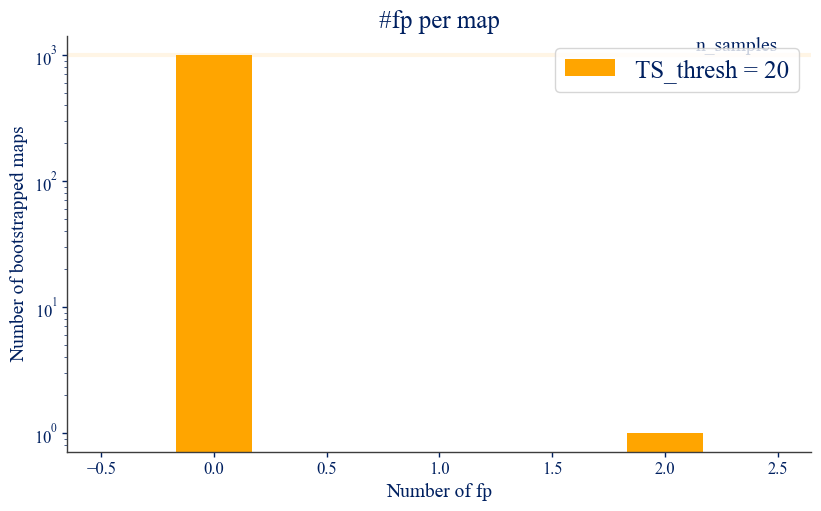

In [12]:
TS_threshold = 20                # 20 = 4.5^2
mask = np.where(ts_results > TS_threshold, 1, 0)

plt.hist(np.sum(mask, axis=1), bins=np.linspace(-0.5, 2.5, 10), label=f'TS_thresh = {TS_threshold}')
plt.axhline(1000, alpha=0.1)
plt.annotate('n_samples', (2.5, 1000), ha='right', va='bottom', fontsize=14)
plt.yscale('log')
plt.xlabel('Number of fp')
plt.ylabel('Number of bootstrapped maps')
plt.title('#fp per map', fontsize=18)
plt.legend(loc='upper right', fontsize=18)
plt.show()

Interpretation: 95% of the times, the map containing 3072 pixels does not contain any false positives. 5% of the times, it may/can contain a/many false positive(s). (This interpretation is based on the xkcd jelly bean comic wherein the jelly bean colors are akin to the pixels - the 95% confidence threshold is adapted / Sidak-corrected to repeatedly perform the test for different colors / pixels - and the total sample space is all jelly beans / 1 single map.)
By creating 1000 such maps, I am essentially estimating the false positive percentages 95 and 5. 

In [210]:
np.mean(np.any(mask, axis=1))

0.035

In [4]:
ts_results = np.load('ts_results.npy')

In [9]:
np.sum(np.sum(mask, axis=1) > 0)

382

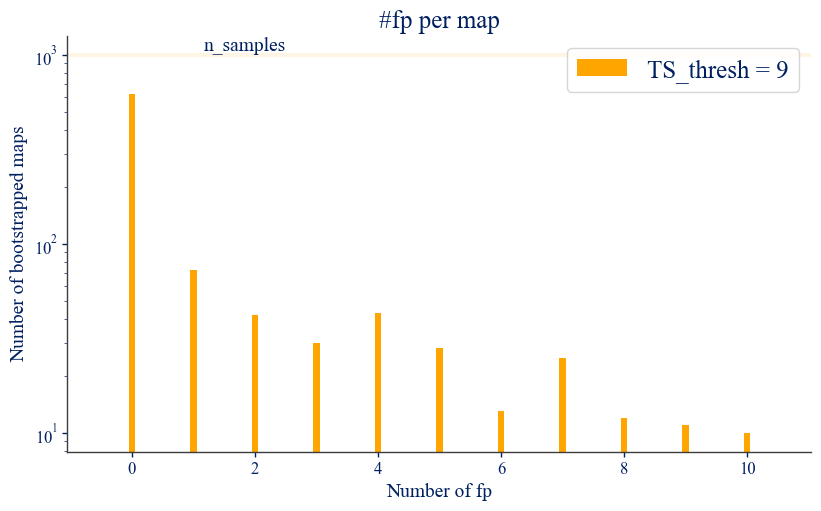

In [11]:
TS_threshold = 9
mask = np.where(ts_results > TS_threshold, 1, 0)

plt.hist(np.sum(mask, axis=1), bins=np.linspace(-0.5, 10.5, 100), label=f'TS_thresh = {TS_threshold}')
plt.axhline(1000, alpha=0.1)
plt.annotate('n_samples', (2.5, 1000), ha='right', va='bottom', fontsize=14)
plt.yscale('log')
plt.xlabel('Number of fp')
plt.ylabel('Number of bootstrapped maps')
plt.title('#fp per map', fontsize=18)
plt.legend(loc='upper right', fontsize=18)
plt.show()

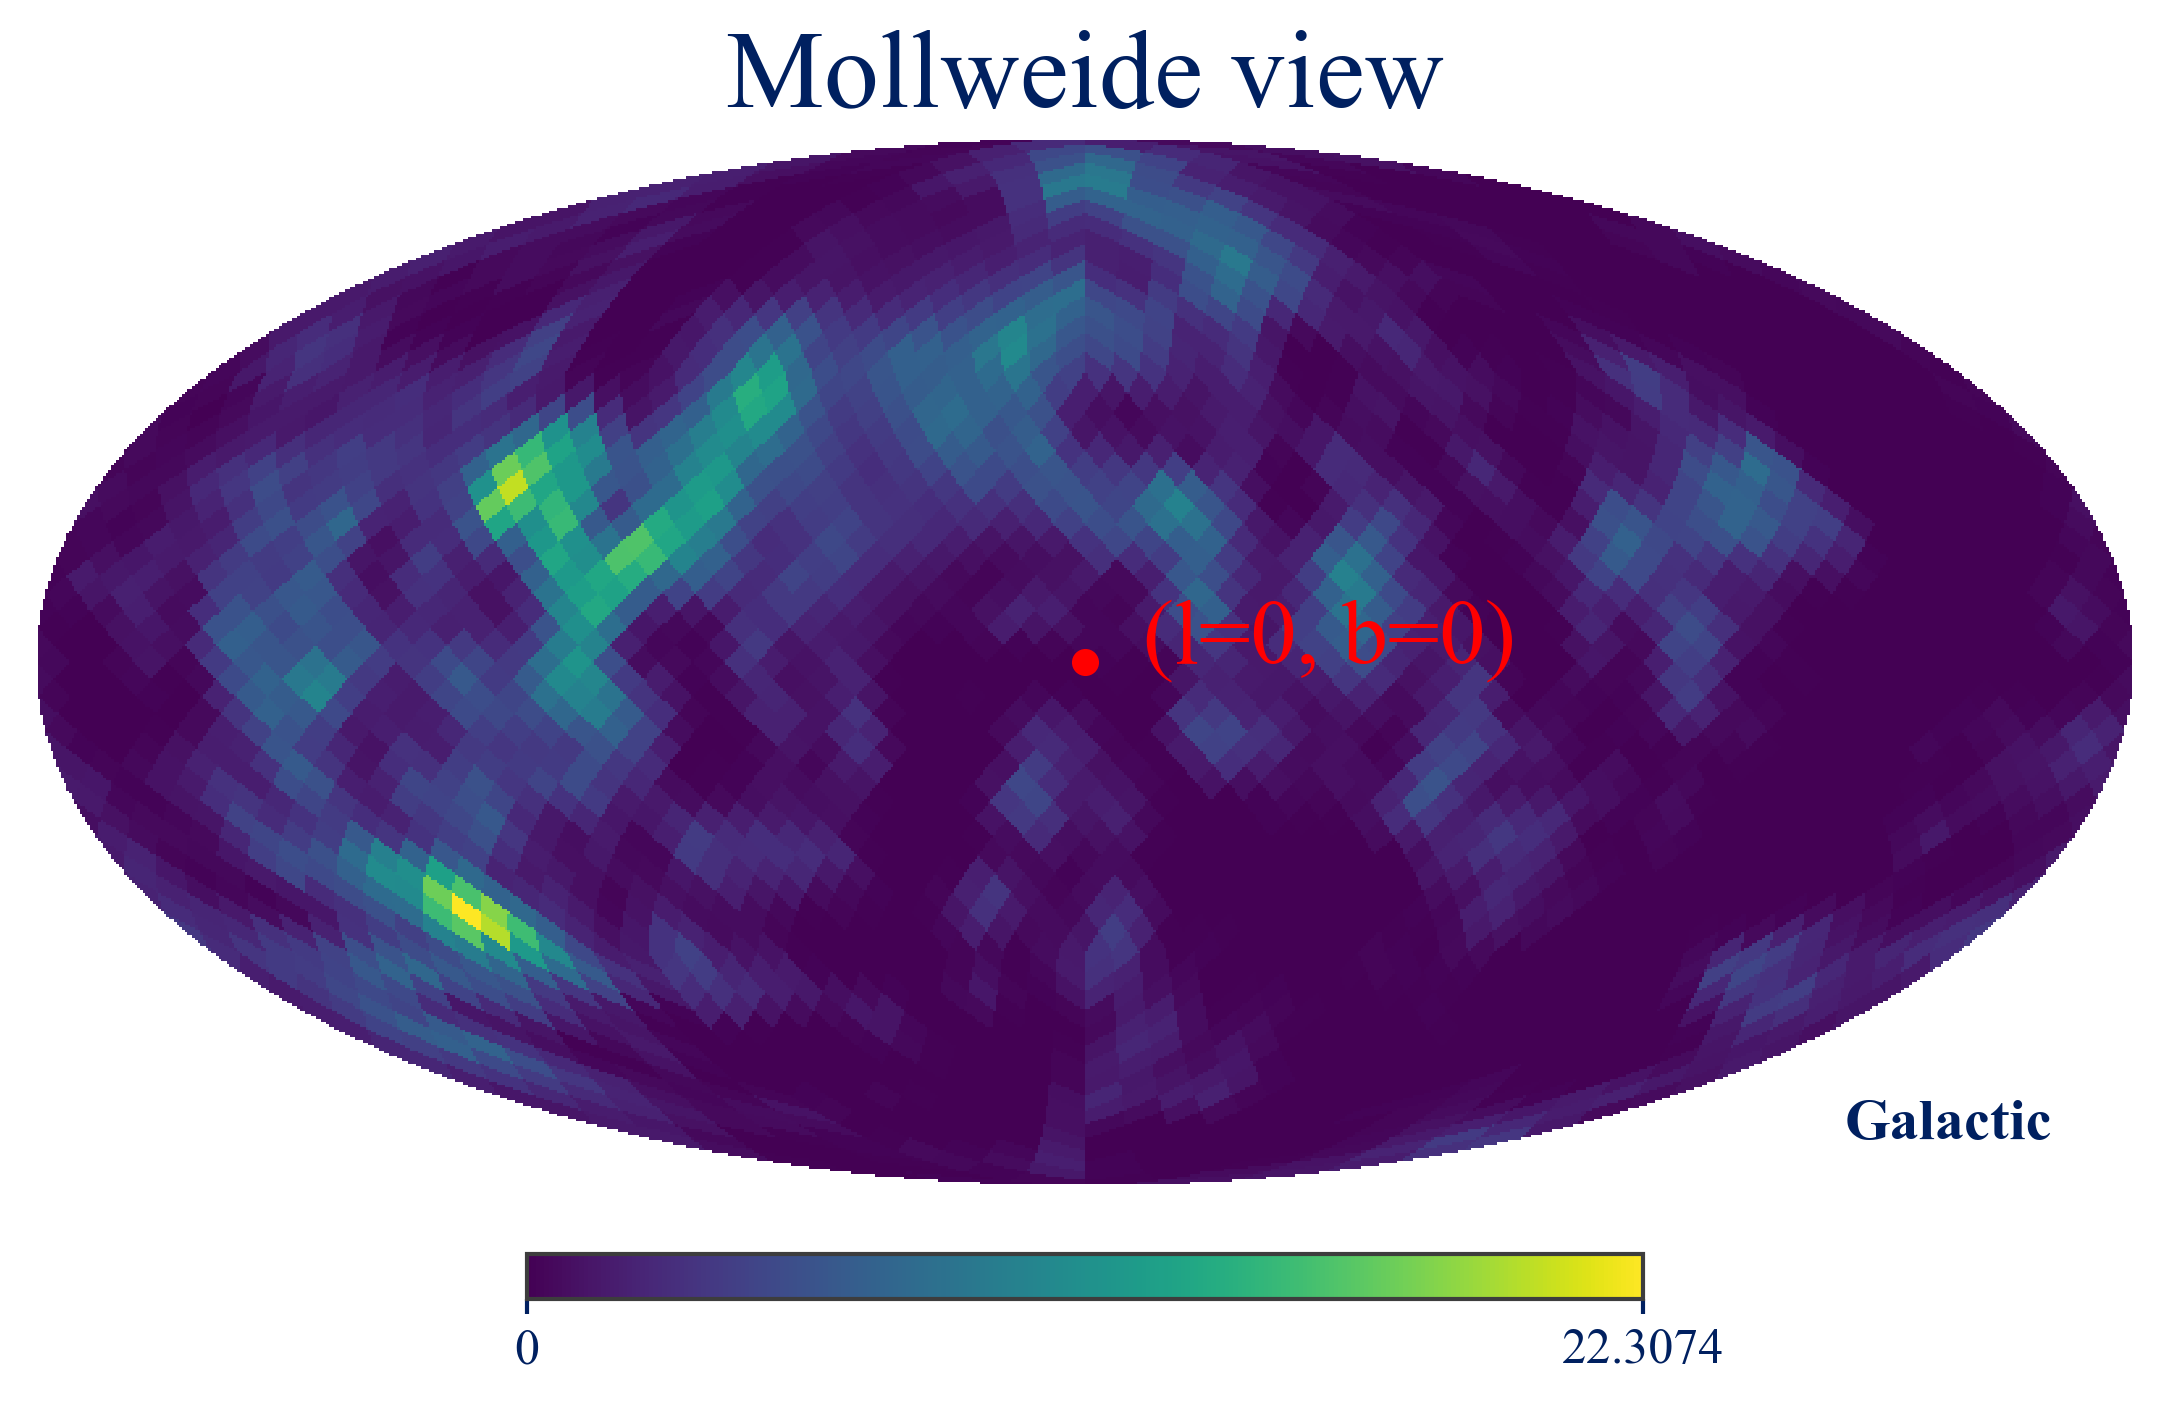

In [143]:
ts.plot_ts(ts_results[101], skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)
# ts.plot_ts(np.where(ts_results[101] > 20, 1, 0), skycoord = None, containment = None, scheme="nested",
#             save_plot = False, dpi = 300)

In [ ]:
ts.plot_ts(ts_results[101], skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)
# ts.plot_ts(np.where(ts_results[101] > 20, 1, 0), skycoord = None, containment = None, scheme="nested",
#             save_plot = False, dpi = 300)

TypeError: expected str, bytes or os.PathLike object, not NoneType

### Background

#### Binned

In [6]:
# To extract binned data

bg = BinnedData("inputs.yaml")

In [7]:
bg.time_bins = 86400*93       # Specifies size of time bin to full 3 month width
bg_filename = DATA_DIR / f'data/backgrounds/binned/gal_DC4_bkg_Ti44_binned_smoothed_fwhm_10.0deg.hdf5'

bg.energy_bins

[1154.0, 1160.0]

In [8]:
bg.load_binned_data_from_hdf5(bg_filename)

#### TS Calculation

In [9]:
background_counts_model = bg.binned_data.project('Em','Phi','PsiChi').todense()
tau = 92.35 * 86400     # Exact exposure time in seconds
lambda_b = background_counts_model / tau
lambda_s = 0.

In [10]:
background_counts_model.contents.max()

5.548115891346962

In [11]:
def get_poisson_log_like(value, lam):
    value = np.asarray(value)
    return -lam + value * np.log(lam) - gammaln(value+1)

def get_poisson_like(value, lam, threshold=1e-6):
    log_p = get_poisson_log_like(value, lam)
    # Convert to probability
    p = np.exp(log_p)
    # Zero out small values
    p[p < threshold] = 0.0
    return p

In [12]:
get_poisson_like(np.arange(15), lam=5.).sum()      # Increase np.arange for even higher precision

0.9997737463238227

In [ ]:
# Define grid size and create grid
loc_br = tau * lambda_b
loc_sr = lambda lambda_s: tau * (lambda_s + lambda_b)
n_sr, n_br = np.meshgrid(np.arange(loc_sr(0)//4, 3*loc_sr(0), 1), np.arange(loc_br//4, 3*loc_br, 1))
prob_br = get_poisson_like(n_br, lam=loc_br)
prob_sr = get_poisson_like(n_sr, lam=loc_sr(0))
dn_sr = n_sr[0,1] - n_sr[0,0] 
dn_br = n_br[1,0] - n_br[0,0]

In [82]:
def get_SNR(n_sr, n_br):
    return (n_sr - n_br) / np.sqrt(n_sr + n_br)

In [12]:
def false_positive_prob_mc(lam_br, lam_sr, n_samples=100000):
    # Sample background counts
    n_br = np.random.poisson(lam=lam_br, size=n_samples)
    # Sample signal+background counts
    n_sr = np.random.poisson(lam=lam_sr, size=n_samples)
    
    # Define your false positive condition
    # Example: sr looks like signal but is actually background
    # false_pos = np.where(get_SNR(n_sr, n_br) > 3, 1, 0)  # SNR threshold set to 3
    false_pos = np.where(get_SNR(n_sr, n_br) > 3, 1, 0)  # SNR threshold set to 3
    
    return np.mean(false_pos)       # np.mean is not arbitrary — it’s the Monte Carlo estimator 
                                    # of the probability I need. It replaces the explicit sum/
                                    # integral I was doing with the grid.

In [ ]:
F = 1e-6 * u.ph / u.cm / u.cm / u.s
mu = 1173.2 * u.keV
sigma = 5 * u.keV

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value 
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.unit = sigma.unit

In [14]:
counts = psr.get_counts(1816)

# counts = np.sum(counts, axis=psr.axes.label_to_index("Em") - 1, dtype=psr.dtype)

# counts = counts.reshape(counts.shape[0], -1)

# psr_sum = np.sum(counts, axis=1)
# valid_cells = np.where(np.logical_and(data_cds_array > 0,
#                                         bkg_model_cds_array > 0))[0]
# psr = counts[:, self.valid_cells]

flux = get_integrated_spectral_model(spectrum, psr.axes["Ei"])
ei_weights = flux.contents.value

# ei_sum = np.dot(psr_sum, ei_weights)
ei_sum = np.sum(counts)*ei_weights[0]
ei_cds_array = np.tensordot(counts, ei_weights, axes=(0,0))

In [15]:
loc_br = tau * lambda_b
loc_sr = lambda lambda_s: tau * (lambda_s + lambda_b)

In [16]:
n_samples = 1000

# flat = loc_br.contents.ravel()  # flatten lam
# # generate samples for each element in lam
# samples = np.random.poisson(flat, size=(n_samples, flat.size))
# # reshape back to (n_samples, *lam.shape)
# n_br = samples.reshape((n_samples, *loc_br.shape))

flat = loc_sr(0).contents.ravel()  # flatten lam
# generate samples for each element in lam
samples = np.random.poisson(flat, size=(n_samples, flat.size))
# reshape back to (n_samples, *lam.shape)
n_sr = samples.reshape((n_samples, *loc_sr(0).shape))

In [16]:
# Instantiate the solver
fnf = FastNormFit()

# Assume you already prepared these arrays externally:
# data_cds_array : np.ndarray of observed counts
# bkg_model_cds_array : np.ndarray of background model counts
# ei_cds_array : np.ndarray of unit excess counts (per norm=1)
# ei_sum : float, sum of unit excess over all CDS cells

# Perform the solve call directly
result = fnf.solve(n_sr[0].ravel(),
                   loc_br.contents.ravel(),
                   ei_cds_array.ravel(),
                   ei_sum)

# result is typically [ts value, norm, norm_err, failed, # iterations]
print(result)

: 

In [95]:
false_positive_prob_mc(300, 0, n_samples=1000000)

0.001382

### Source Injector - False Negative

In [ ]:
CasAsymmetric = 'CasAsymmetric', 111.734745, -2.129570, 3e-4        # 1000 km/s

SN1987A = 'SN1987A', 279.7, -31.9, 7e-6
Tycho = 'Tycho', 120.1, +1.4, 16e-6
Kepler = 'Kepler', 4.5, +6.8, 10e-6 
VelaJr = 'VelaJr', 266.3, -1.2, 28e-6
G1903 = 'G1903', 1.9, +0.3, 10e-6

STS1 = 'STS1', 80.2, +0.8, 1e-6
STS2 = 'STS2', 81.2, +0.9, 2e-6
STS3 = 'STS3', 84.0, -1.3, 1e-6
STS4 = 'STS4', 283.8, +75.5, 2e-6
STS5 = 'STS5', 184.6, -5.8, 1e-6
STS6 = 'STS6', 266.3, -49.7, 1e-6

known_SNRs = [SN1987A, Tycho, Kepler, VelaJr, G1903]
STS_SNRs = [STS1, STS2, STS3, STS4, STS5, STS6]

In [ ]:
betas = []
for lambda_s in signal_strength:
    cond = np.where(get_SNR(n_sr, n_br) > SNR_thresh)       # Replace with get_ts_lrt()
    prob_br = get_poisson_like(n_br[cond], lam=loc_br)
    prob_sr = get_poisson_like(n_sr[cond], lam=loc_sr(lambda_s))
    betas.append(np.sum(prob_br * prob_sr) * dn_br * dn_sr)
betas = np.array(betas)

# Plot
plt.plot(signal_strength * tau, betas)
plt.xlabel('$\\tau * \lambda_s$')
plt.ylabel('Beta')
if key not in ['2008A', '2008B', '2011A', '2011B']:
    plt.xlim([0, 900])
else:
    plt.xlim([0, 300])

betas = np.array(betas)
for beta_thresh in [0.5, 0.9, 0.95]:
    idx = np.argmin(np.abs(betas - beta_thresh))
    plt.axvline(tau*signal_strength[idx], lw=1, color='gray')
    plt.axhline(betas[idx], lw=1, ls='--', color='gray')
    print(beta_thresh, (tau * signal_strength[idx]).round(0), signal_strength[idx].round(5))

ax = plt.gca().twiny()
ax.set_xticks(tau * signal_strength[::len(signal_strength)//5])
ax.set_xticklabels(signal_strength[::len(signal_strength)//5].round(5))
ax.set_xlabel('$\lambda_s$')
plt.show()